# Parse Tree Visualizations

This notebook demonstrates how to generate and visualize parse trees from hearing utterances using the Tokenizer class and NLTK.

In [1]:
import pandas as pd
import random
from pathlib import Path

from src import HearingLoader, HearingTagger
from src.grammar.Tokenizer import Tokenizer
from src.grammar.Parser import Parser
from src.dataclasses.Hearing import TaggedHearing

# Set random seed for reproducibility
random.seed(42)

In [2]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


In [3]:
# Load hearings from utterances_sample.csv
utterances_df = pd.read_csv('./utterances_sample.csv')

# Initialize loader and tagger
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()

hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']
print(len(hearings))
print(len(relevant_hearings))

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
8218
7069


In [4]:
import random

# Set random seed for reproducibility
random.seed(42)

# Randomly sample 20 hearings
sampled_hearings = random.sample(relevant_hearings, 5)
sampled_hearings = [tagger(h) for h in sampled_hearings]
sampled_hearings = [h for h in sampled_hearings if h is not None]

In [5]:
# Display the sampled hearings
sampled_hearings

[TaggedHearing(hid=254831, bid='CA_201720180SCA22', cid=587, cname='Senate Standing Committee on Governance and Finance', hearing_date=datetime.datetime(2018, 5, 9, 0, 0), state='CA', speakers={93: Speaker(can_file_motions=True, is_presenter=False, speaker_position=<SpeakerPositionEnum.PRESIDING_CHAIR: 8>, first_mention_uid=38, first_uid=0, last_uid=41, pid=93, first_name='Mike', last_name='McGuire'), 70: Speaker(can_file_motions=False, is_presenter=True, speaker_position=<SpeakerPositionEnum.BILL_AUTHOR: 4>, first_mention_uid=0, first_uid=1, last_uid=40, pid=70, first_name='Benjamin', last_name='Allen'), 4657: Speaker(can_file_motions=True, is_presenter=False, speaker_position=<SpeakerPositionEnum.COMMITTEE_MEMBER: 5>, first_mention_uid=2, first_uid=5, last_uid=27, pid=4657, first_name='John', last_name='Moorlach'), 8476: Speaker(can_file_motions=False, is_presenter=False, speaker_position=<SpeakerPositionEnum.PUBLIC: 0>, first_mention_uid=7, first_uid=7, last_uid=7, pid=8476, first_n

In [6]:
print(sampled_hearings[4])

State:		CA
Committee:	Assembly Standing Committee on Local Government
Bill:		CA_201720180AB546
Date:		2017-04-05


Transcript:
David Chiu: [BILL_AUTHOR]:
great thank you madam chair colleagues first of all i'd appreciate it if we could take up BILL first I know our witnesses are right here if that's okay colleagues ORG would advance energy storage technology in our state by requiring the development of a GPE energy storage permitting guidebook and requiring cities and counties to accept electronic submission of permit applications for energy storage installations as you know our state is becoming more reliant on a variety of renewable energy resources and we need options to allow for the flexible management of electric supply and demand energy storage allows customers to use power when it is cheapest and most plentiful and creates resource stability for grid operators while this technology is not new and currently deployed in some jurisdictions we are expecting strong growth throughout

In [7]:
# Initialize the parser
parser = Parser()

# Generate parse trees for sampled hearings
parse_results = []

for hearing in sampled_hearings:
    result = {
        'tokens': parser.tokenizer.tokenize_utterances(hearing),
        'nltk_tree': None,
        'all_parses': []
    }
    parse_node = parser.parse(hearing)
    
    # Get NLTK tree if parse succeeded
    if parse_node:
        result['nltk_tree'] = parse_node.to_nltk_tree()
        # Also get alternative parses
        result['all_parses'] = parser.get_all_parses_as_nltk_trees(hearing, max_parses=3)
    
    parse_results.append(result)
    
print(f"\nParse results:")
for i, r in enumerate(parse_results):
    status = "✓ Success" if r['nltk_tree'] is not None else "✗ Failed"
    num_tokens = len(r['tokens'])
    num_parses = len(r['all_parses'])
    print(f"  {sampled_hearings[i].bid}:\t{status}\t({num_tokens} tokens, {num_parses} possible parses)")


Parse results:
  CA_201720180SCA22:	✓ Success	(42 tokens, 1 possible parses)
  CA_201720180AB2601:	✓ Success	(20 tokens, 1 possible parses)
  CA_201720180AB1062:	✓ Success	(8 tokens, 1 possible parses)
  CA_20172018BUD3940:	✓ Success	(20 tokens, 1 possible parses)
  CA_201720180AB546:	✓ Success	(13 tokens, 1 possible parses)


## Visualize Parse Trees

Now we'll visualize the parse trees using NLTK's tree visualization capabilities.

In [8]:
# Display parse trees for each hearing
for i, result in enumerate(parse_results):
    print(f"\n{'='*80}")
    print(f"Hearing {i+1}")
    print(f"{'='*80}")
    print(sampled_hearings[i])
    
    # Show token sequence
    print("\nToken sequence (SpeakerPositionEnum):")
    token_names = [token[0].name for token in result['tokens']]
    print("  " + " -> ".join(token_names[:10]) + ("..." if len(token_names) > 10 else ""))
    
    if result['nltk_tree']:
        print(f"\nFound {len(result['all_parses'])} possible parse(s)")
        # print("\nPrimary Parse Tree:")
        # print(result['nltk_tree'])
        print("\nPretty Print:")
        result['nltk_tree'].pretty_print()
    else:
        print("\n⚠ No valid parse found for this hearing")
        print("This may indicate that the utterance sequence doesn't match any grammar rules.")


Hearing 1
State:		CA
Committee:	Senate Standing Committee on Governance and Finance
Bill:		CA_201720180SCA22
Date:		2018-05-09


Transcript:
Mike McGuire: [PRESIDING_CHAIR]:
we're moving to BILL which is a constitutional amendment 22 senator BILL_AUTHOR this is in regards to school districts and parcel taxes we welcome the good senator the chair of education to the ORG the floor is yours sir


Benjamin Allen: [BILL_AUTHOR]:
members many of you know that I came to this position having served for two terms on school board in my hometown of GPE and I was elected in 2008 and literally I think that I was on the ballot for the november election and in october the stock market crashed the subprime mortgage hit full disaster mode and basically my entire time on the school board was spent trying to figure out ways to balance the budget keep our financial controls in place while also making sure we did everything we could to preserve and protect the core programs that made such a difference for

## Summary Statistics

In [9]:
# Summary statistics
successful_parses = sum(1 for r in parse_results if r['nltk_tree'] is not None)
ambiguous_parses = sum(1 for r in parse_results if len(r['all_parses']) > 1)

print("Parse Tree Generation Summary")
print("=" * 50)
print(f"Total hearings processed: {len(parse_results)}")
print(f"Successful parses: {successful_parses} ({successful_parses/len(parse_results)*100:.1f}%)")
print(f"Failed parses: {len(parse_results) - successful_parses}")
print(f"Ambiguous parses (multiple valid trees): {ambiguous_parses}")
print()

# Token statistics
all_tokens = [token for r in parse_results for token in r['tokens']]
print(f"Total tokens across all hearings: {len(all_tokens)}")

# Distribution of speaker positions
from collections import Counter
token_distribution = Counter([token[0].name for token in all_tokens])
print("\nToken distribution (SpeakerPositionEnum):")
for pos, count in token_distribution.most_common():
    print(f"  {pos}: {count} ({count/len(all_tokens)*100:.1f}%)")

Parse Tree Generation Summary
Total hearings processed: 5
Successful parses: 5 (100.0%)
Failed parses: 0
Ambiguous parses (multiple valid trees): 0

Total tokens across all hearings: 103

Token distribution (SpeakerPositionEnum):
  PRESIDING_CHAIR: 41 (39.8%)
  PUBLIC: 18 (17.5%)
  EXPERT: 16 (15.5%)
  BILL_AUTHOR: 14 (13.6%)
  COMMITTEE_MEMBER: 11 (10.7%)
  SECRETARY: 3 (2.9%)


## Saving Results

Save the parse trees for later analysis.

In [10]:
# import pickle

# # Save parse results
# output_file = "parse_tree_results.pkl"
# with open(output_file, 'wb') as f:
#     pickle.dump(parse_results, f)

# print(f"Parse results saved to: {output_file}")
# print("\nTo load later:")
# print("  with open('parse_tree_results.pkl', 'rb') as f:")
# print("      parse_results = pickle.load(f)")

## Export Trees as String Representations

For documentation or reporting purposes, export the tree structures.

In [11]:
# Export tree strings to a text file
output_text_file = "parse_trees.txt"

with open(output_text_file, 'w', encoding='utf-8') as f:
    for i, result in enumerate(parse_results):
        f.write(f"{'='*80}\n")
        f.write(f"Hearing {i+1}: {sampled_hearings[i].bid} (hid: {sampled_hearings[i].hid})\n")
        f.write(f"{'='*80}\n\n")
        
        if result['nltk_tree']:
            f.write("Parse Tree (bracket notation):\n")
            f.write(str(result['nltk_tree']))
            f.write("\n\n")
            
            if len(result['all_parses']) > 1:
                f.write(f"Alternative parses: {len(result['all_parses']) - 1}\n\n")
        else:
            f.write("No valid parse found\n\n")
        
        f.write("\n")

print(f"Parse trees exported to: {output_text_file}")

Parse trees exported to: parse_trees.txt


# Section speaker position requirements

Found 8 sections with speaker position rules:
  INTRO: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)']
  PRESENTATION: ['PRESIDING_CHAIR(8)', 'BILL_AUTHOR(4)']
  LEGISLATOR_DISCUSSION: ['PRESIDING_CHAIR(8)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)', 'LEGISLATOR(3)', 'EXPERT(2)', 'NONLEGISLATOR(1)']
  EXPERT_TESTIMONY: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)', 'LEGISLATOR(3)', 'EXPERT(2)', 'NONLEGISLATOR(1)']
  PUBLIC_COMMENTS: ['PRESIDING_CHAIR(8)', 'COMMITTEE_MEMBER(5)', 'NONLEGISLATOR(1)', 'PUBLIC(0)']
  CLOSING_REMARKS: ['PRESIDING_CHAIR(8)', 'BILL_AUTHOR(4)', 'LEGISLATOR(3)']
  VOTE: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)', 'LEGISLATOR(3)']
  OTHER: ['PRESIDING_CHAIR(8)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)', 'LEGISLATOR(3)']


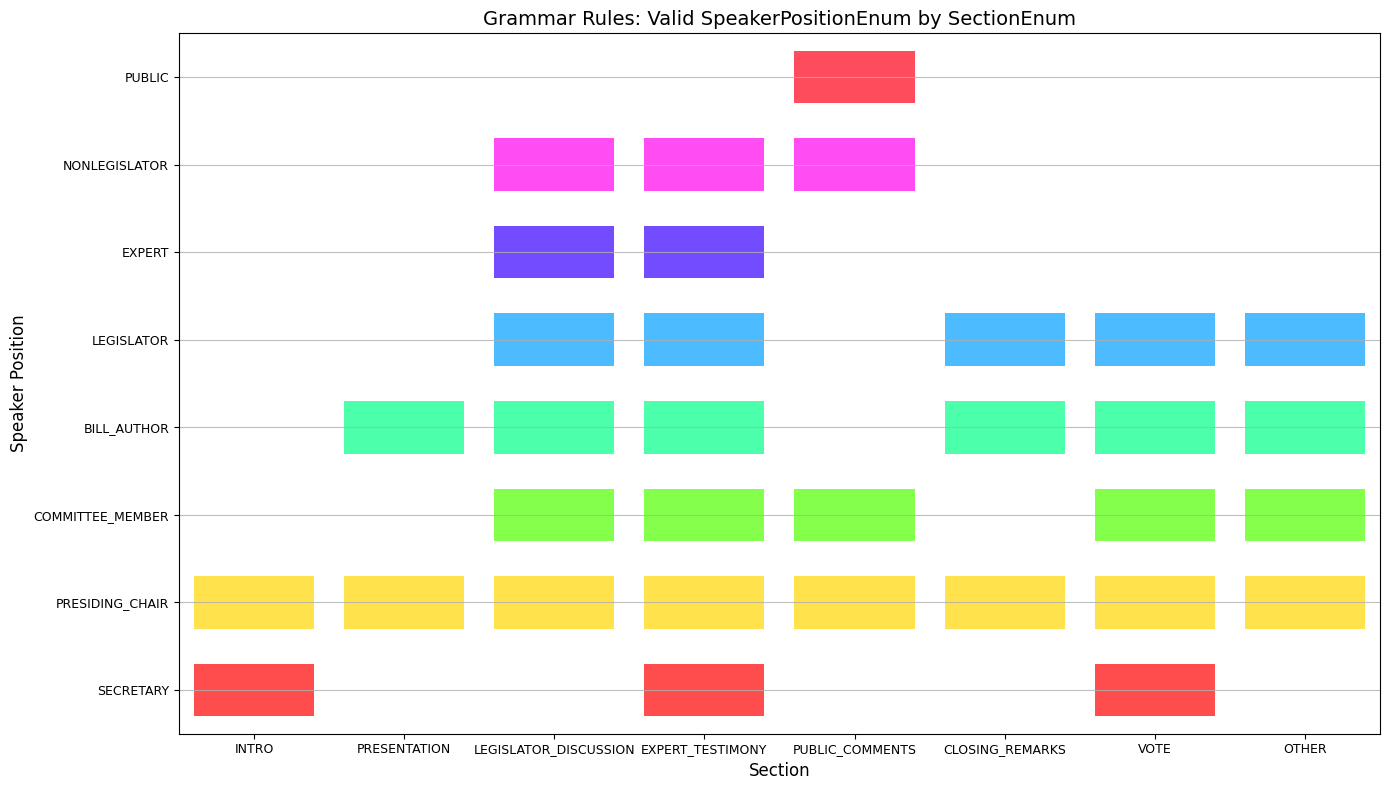

In [12]:
from src.grammar.Grammar import GRAMMAR
from src.enums.SectionEnum import SectionEnum
from src.visualizations.SectionSpeakerRulePlotter import SectionSpeakerRulePlotter

plotter = SectionSpeakerRulePlotter(GRAMMAR)
plotter.plot()